# GRA: rel adam + cifar

project = ```GRA```, host = ```chewie```, device = ```cuda:0```

## Goals:

In [1]:
# HIDE CODE


project_name = '_GRA'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Main

In [3]:
from optimzers import *
from test.test import *

### CIFAR10

`batch_size=256`

In [4]:
cfg = TrainConfig(
    dataset='CIFAR10',
    # dataset='ImageNet32',
    batch_size=256,
    epochs=200,
    device=device,
    data_on_device=True,
    verbose=True,
    amp=False,
)

### Intermediate coupling

In [5]:
# opt_kws = dict(lr=1e-3, betas=(0.9, 0.999), weight_decay=0.0)

experiments = [
    Experiment(
        name='Relativistic Adam (C=0.001,lr=0.01,inert_src=False)',
        opt_fn=make_opt(RelativisticAdam,
                        coupling=1e-3,
                        lr=1e-2,
                        inertial_sourcing=False,)),
    Experiment(
        name='Relativistic Adam (C=0.01,lr=0.01,inert_src=False)',
        opt_fn=make_opt(RelativisticAdam,
                        coupling=0.01,
                        lr=1e-2,
                        inertial_sourcing=False,)),
    Experiment(
        name='Relativistic Adam (C=0.1,lr=0.01,inert_src=False)',
        opt_fn=make_opt(RelativisticAdam,
                        coupling=0.1,
                        lr=1e-2,
                        inertial_sourcing=False,)),
    Experiment(
        name='Relativistic Adam (C=0.01,lr=0.01,inert_src=True)',
        opt_fn=make_opt(RelativisticAdam,
                        coupling=0.01,
                        lr=1e-2,
                        inertial_sourcing=True,)),
    Experiment(
        name='Relativistic Adam (C=100,lr=0.01,inert_src=False)',
        opt_fn=make_opt(RelativisticAdam,
                        coupling=100,
                        lr=1e-2,
                        inertial_sourcing=False,)),
    Experiment(
        name='AdamW',
        opt_fn=make_opt(torch.optim.AdamW, lr=1e-2)),
]

print(len(experiments))

6

In [6]:
print(experiments)

[
    Experiment(
        name='Relativistic Adam (C=0.001,lr=0.01,inert_src=False)',
        opt_fn=<function make_opt.<locals>._fn at 0x7e5a91608ea0>
    ),
    Experiment(
        name='Relativistic Adam (C=0.01,lr=0.01,inert_src=False)',
        opt_fn=<function make_opt.<locals>._fn at 0x7e5a91609260>
    ),
    Experiment(
        name='Relativistic Adam (C=0.1,lr=0.01,inert_src=False)',
        opt_fn=<function make_opt.<locals>._fn at 0x7e5a91609440>
    ),
    Experiment(
        name='Relativistic Adam (C=0.01,lr=0.01,inert_src=True)',
        opt_fn=<function make_opt.<locals>._fn at 0x7e5a8fb759e0>
    ),
    Experiment(
        name='Relativistic Adam (C=100,lr=0.01,inert_src=False)',
        opt_fn=<function make_opt.<locals>._fn at 0x7e5a8fb75a80>
    ),
    Experiment(name='AdamW', opt_fn=<function make_opt.<locals>._fn at 0x7e5a8fb75b20>)
]

In [7]:
%%time


results = run_experiments(experiments, cfg=cfg, seeds=[0])

--- Training (CIFAR10) ---

Model: ConvNet | seed=0
Optimizer: RelativisticAdam

RelativisticAdam (
Parameter Group 0
    betas: (0.9, 0.999)
    coupling: 0.001
    eps: 1e-08
    inertial_sourcing: False
    lr: 0.01
    weight_decay: 0.0
)

Epoch    1/200:  Train Loss 18.3697  |  Test Acc 17.00%

Epoch    5/200:  Train Loss 1.2781  |  Test Acc 59.60%

Epoch   10/200:  Train Loss 0.7644  |  Test Acc 73.05%

...

Epoch  190/200:  Train Loss 0.2271  |  Test Acc 83.78%

Epoch  195/200:  Train Loss 0.2356  |  Test Acc 83.24%

Epoch  200/200:  Train Loss 0.2235  |  Test Acc 84.50%

Finished in 581.3s

CPU times: user 1h 3min 8s, sys: 6.15 s, total: 1h 3min 14s
Wall time: 1h 3min 12s


In [8]:
avg_scores = {k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Relativistic Adam (C=100,lr=0.01,inert_src=False)': 10.0,
 'Relativistic Adam (C=0.001,lr=0.01,inert_src=False)': 81.13,
 'Relativistic Adam (C=0.01,lr=0.01,inert_src=True)': 83.01,
 'Relativistic Adam (C=0.1,lr=0.01,inert_src=False)': 83.76,
 'AdamW': 84.01,
 'Relativistic Adam (C=0.01,lr=0.01,inert_src=False)': 86.98}

{'Relativistic Adam (C=1.0,inert_src=True)': 85.88,
 'Relativistic Adam (C=1.0,inert_src=False)': 88.61,
 'AdamW': 88.81}

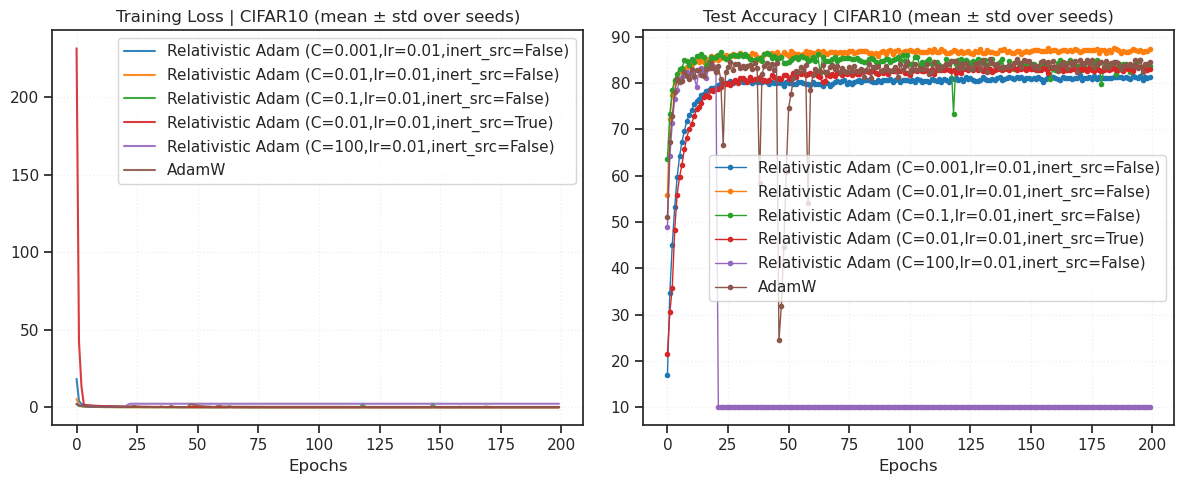

In [9]:
plot_results(results, title="CIFAR10 (mean ± std over seeds)")

### Intermediate coupling, low momenta

In [11]:
opt_kws = dict(lr=1e-3, betas=(0.8, 0.99), weight_decay=0.0)

experiments = [
    Experiment(
        name='Relativistic Adam (C=1.0,inert_src=True)',
        opt_fn=make_opt(RelativisticAdam,
                        coupling=1.0,
                        inertial_sourcing=True,
                        **opt_kws)),
    Experiment(
        name='Relativistic Adam (C=1.0,inert_src=False)',
        opt_fn=make_opt(RelativisticAdam,
                        coupling=1.0,
                        inertial_sourcing=False,
                        **opt_kws)),
    Experiment(
        name='AdamW',
        opt_fn=make_opt(torch.optim.AdamW, **opt_kws)),
]

print(len(experiments))

3

In [12]:
print(experiments)

[
    Experiment(
        name='Relativistic Adam (C=1.0,inert_src=True)',
        opt_fn=<function make_opt.<locals>._fn at 0x7fbb587a85e0>
    ),
    Experiment(
        name='Relativistic Adam (C=1.0,inert_src=False)',
        opt_fn=<function make_opt.<locals>._fn at 0x7fbb586a07c0>
    ),
    Experiment(name='AdamW', opt_fn=<function make_opt.<locals>._fn at 0x7fbb586a0400>)
]

In [13]:
%%time


results = run_experiments(experiments, cfg=cfg, seeds=[0])

--- Training (CIFAR10) ---

Model: ConvNet | seed=0
Optimizer: RelativisticAdam

RelativisticAdam (
Parameter Group 0
    betas: (0.8, 0.99)
    coupling: 1.0
    eps: 1e-08
    inertial_sourcing: True
    lr: 0.001
    weight_decay: 0.0
)

Epoch    1/300:  Train Loss 1.4710  |  Test Acc 64.57%

Epoch    5/300:  Train Loss 0.3857  |  Test Acc 80.61%

Epoch   10/300:  Train Loss 0.1525  |  Test Acc 84.56%

...

Epoch  290/300:  Train Loss 0.0121  |  Test Acc 88.92%

Epoch  295/300:  Train Loss 0.0117  |  Test Acc 88.67%

Epoch  300/300:  Train Loss 0.0130  |  Test Acc 88.73%

Finished in 921.9s

CPU times: user 47min 11s, sys: 6.04 s, total: 47min 17s
Wall time: 47min 16s


In [14]:
avg_scores = {k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Relativistic Adam (C=1.0,inert_src=True)': 83.69,
 'Relativistic Adam (C=1.0,inert_src=False)': 88.35,
 'AdamW': 88.63}

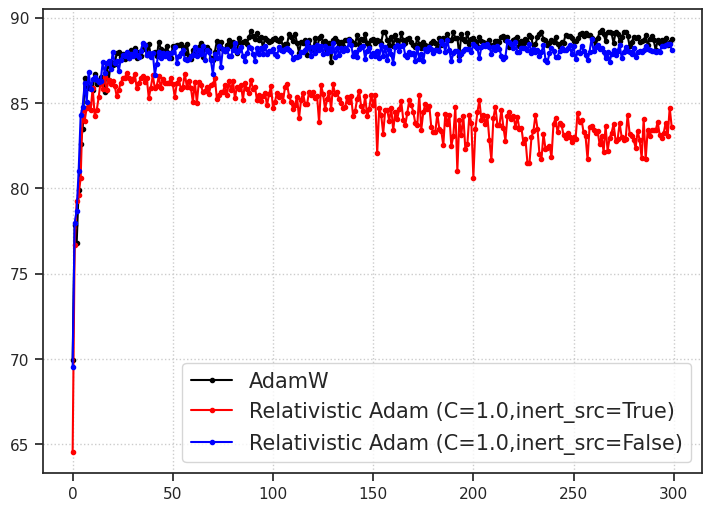

In [15]:
fig, ax = create_figure(1, 1, (7, 5))
ax.plot(results['AdamW']['test_acc'].squeeze(),
        color='k', marker='.', label='AdamW')
ax.plot(results['Relativistic Adam (C=1.0,inert_src=True)']['test_acc'].squeeze(),
        color='r', marker='.', label='Relativistic Adam (C=1.0,inert_src=True)')
ax.plot(results['Relativistic Adam (C=1.0,inert_src=False)']['test_acc'].squeeze(),
        color='b', marker='.', label='Relativistic Adam (C=1.0,inert_src=False)')
ax.legend(fontsize=15)
ax.grid()
plt.show()

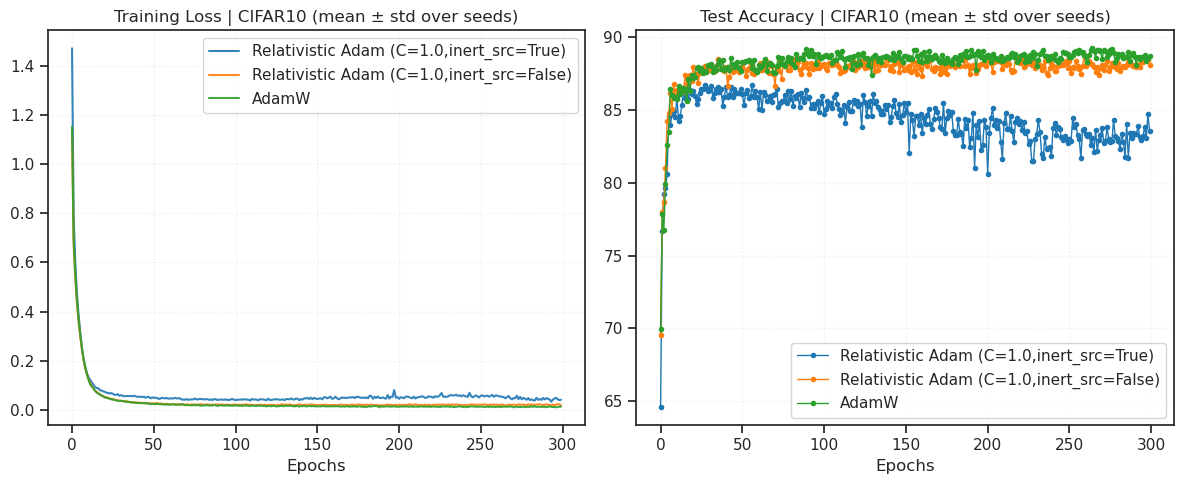

In [17]:
plot_results(results, title="CIFAR10 (mean ± std over seeds)")

In [18]:
avg_scores = {k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Relativistic Adam (C=1.0,inert_src=True)': 83.69,
 'Relativistic Adam (C=1.0,inert_src=False)': 88.35,
 'AdamW': 88.63}

In [19]:
import torch
import math
from torch.optim import Optimizer

class TurboAdam(Optimizer):
    """
    Implements Turbulent Adam (TurboAdam).

    A physics-derived optimizer that replaces simple viscous friction with
    Fluid Dynamic Drag. It models the parameter updates as a particle moving
    through a medium where drag transitions from Laminar (Linear) to
    Turbulent (Quadratic) as speed increases.

    Mechanism:
    - Low gradients (Laminar Flow): Behaves like Standard Adam.
    - High gradients (Turbulent Flow): Quadratic drag kicks in, creating a
      natural "Terminal Velocity" without explicit hard clipping.

    Args:
        params (iterable): Iterable of parameters to optimize.
        lr (float): Learning rate.
        betas (Tuple[float, float]): coefficients used for computing
            running averages of gradient and its square (default: (0.9, 0.999)).
        eps (float): Term added to the denominator to improve
            numerical stability (default: 1e-8).
        weight_decay (float): AdamW-style weight decay (default: 0).
        turbo (float): The Turbulence Coefficient (rho).
            - 0.0 : Laminar flow (Exact Adam behavior).
            - 0.1 : Gentle aerodynamic resistance.
            - 1.0 : Strong air resistance (High stability).
    """

    def __init__(
        self,
        params,
        lr=1e-3,
        betas=(0.9, 0.999),
        eps=1e-8,
        weight_decay=0.0,
        turbo=0.0,  # Default to 0 (Adam) to let user opt-in
        bias_correction=True,
    ):
        if lr < 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if eps < 0.0:
            raise ValueError(f"Invalid epsilon value: {eps}")
        if weight_decay < 0.0:
            raise ValueError(f"Invalid weight_decay value: {weight_decay}")
        if turbo < 0.0:
            raise ValueError(f"Invalid turbo value: {turbo}")

        defaults = dict(
            lr=lr,
            betas=betas,
            eps=eps,
            weight_decay=weight_decay,
            turbo=turbo,
            bias_correction=bias_correction,
        )
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            beta1, beta2 = group["betas"]
            eps = group["eps"]
            wd = group["weight_decay"]
            rho = group["turbo"]

            for p in group["params"]:
                if p.grad is None:
                    continue
                
                grad = p.grad
                if grad.is_sparse:
                    raise RuntimeError("TurboAdam does not support sparse gradients")

                state = self.state[p]

                # State initialization
                if len(state) == 0:
                    state["step"] = 0
                    state["exp_avg"] = torch.zeros_like(p, memory_format=torch.preserve_format)
                    state["exp_avg_sq"] = torch.zeros_like(p, memory_format=torch.preserve_format)

                exp_avg = state["exp_avg"]
                exp_avg_sq = state["exp_avg_sq"]
                state["step"] += 1
                step = state["step"]

                # 1. AdamW-style Weight Decay
                if wd != 0:
                    p.data.mul_(1.0 - lr * wd)

                # 2. Metric Update (The "Fluid" Properties)
                # We update variance first so we can normalize momentum against it
                exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1.0 - beta2)
                
                # 3. Turbulent Momentum Update
                # Calculate the "Reynolds Number" (Dimensionless Speed)
                # z = |p| / sqrt(v)
                metric_psi = exp_avg_sq.sqrt().add(eps)
                
                # Apply Bias Correction to metric for accurate "Speed" estimation
                if group["bias_correction"]:
                    bc2 = 1.0 - beta2 ** step
                    metric_psi.div_(math.sqrt(bc2))

                # Current Speed Estimate (based on previous momentum)
                # This measures how "fast" the parameter is moving relative to the curvature
                current_speed = exp_avg.abs() / metric_psi
                
                # Drag Factor: D = 1 / (1 + rho * speed)
                # This comes from solving dp/dt = -rho * p^2 implicitly over one step
                if rho > 0:
                    drag = 1.0 + rho * current_speed
                    # Apply drag to the OLD momentum (Viscous damping)
                    damped_momentum = exp_avg / drag
                else:
                    damped_momentum = exp_avg

                # Standard Momentum update on the damped vector
                # p_new = beta1 * p_damped + (1-beta1) * g
                exp_avg.copy_(damped_momentum).mul_(beta1).add_(grad, alpha=1.0 - beta1)

                # 4. Parameter Update
                if group["bias_correction"]:
                    bc1 = 1.0 - beta1 ** step
                    bc2 = 1.0 - beta2 ** step # Recalculate if needed, usually cheap
                    denom = exp_avg_sq.sqrt().div(math.sqrt(bc2)).add(eps)
                    step_size = lr / bc1
                else:
                    denom = exp_avg_sq.sqrt().add(eps)
                    step_size = lr

                p.addcdiv_(exp_avg, denom, value=-step_size)

        return loss

In [21]:
cfg = TrainConfig(
    dataset='CIFAR10',
    # dataset='ImageNet32',
    batch_size=256,
    epochs=30,
    device=device,
    data_on_device=True,
    verbose=True,
    amp=False,
)

In [22]:
opt_kws = dict(lr=1e-3, betas=(0.8, 0.99), weight_decay=0.0)

experiments = [
    Experiment(
        name='Turbo Adam (C=1.0,turbo=1.0)',
        opt_fn=make_opt(TurboAdam,
                        turbo=1.0,
                        **opt_kws)),
    Experiment(
        name='Turbo Adam (C=1.0,turbo=0.1)',
        opt_fn=make_opt(TurboAdam,
                        turbo=0.1,
                        **opt_kws)),
    Experiment(
        name='Turbo Adam (C=1.0,turbo=0.0)',
        opt_fn=make_opt(TurboAdam,
                        turbo=0.0,
                        **opt_kws)),
]

print(len(experiments))

3

In [23]:
results = run_experiments(experiments, cfg=cfg, seeds=[0])

--- Training (CIFAR10) ---

Model: ConvNet | seed=0
Optimizer: TurboAdam

TurboAdam (
Parameter Group 0
    betas: (0.8, 0.99)
    bias_correction: True
    eps: 1e-08
    lr: 0.001
    turbo: 1.0
    weight_decay: 0.0
)

Epoch    1/30:  Train Loss 1.0789  |  Test Acc 74.02%

Epoch    2/30:  Train Loss 0.6387  |  Test Acc 76.76%

Epoch    3/30:  Train Loss 0.4965  |  Test Acc 79.90%

...

Epoch   27/30:  Train Loss 0.0407  |  Test Acc 88.39%

Epoch   28/30:  Train Loss 0.0399  |  Test Acc 87.90%

Epoch   29/30:  Train Loss 0.0385  |  Test Acc 88.21%

Epoch   30/30:  Train Loss 0.0360  |  Test Acc 87.35%

Finished in 96.7s

In [24]:
avg_scores = {k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Turbo Adam (C=1.0,turbo=1.0)': 86.91,
 'Turbo Adam (C=1.0,turbo=0.1)': 87.63,
 'Turbo Adam (C=1.0,turbo=0.0)': 87.76}

### Bias correction is good

In [5]:
opt_kws = dict(lr=1e-3, betas=(0.9, 0.999), weight_decay=0.0)

experiments = [
    Experiment( # Should be exactly AdamW
        name='Relativistic Adam (C=inf,inert_src=False,bias_c=True)',
        opt_fn=make_opt(RelativisticAdam,
                        coupling='inf',
                        inertial_sourcing=False,
                        bias_correction=True,
                        **opt_kws)),
    Experiment( # Should be exactly AdamW
        name='Relativistic Adam (C=inf,inert_src=False,bias_c=False)',
        opt_fn=make_opt(RelativisticAdam,
                        coupling='inf',
                        inertial_sourcing=False,
                        bias_correction=False,
                        **opt_kws)),
    Experiment(
        name='Relativistic Adam (C=inf,inert_src=True,bias_c=True)',
        opt_fn=make_opt(RelativisticAdam,
                        coupling='inf',
                        inertial_sourcing=True,
                        bias_correction=True,
                        **opt_kws)),
    Experiment(
        name='Relativistic Adam (C=inf,inert_src=True,bias_c=False)',
        opt_fn=make_opt(RelativisticAdam,
                        coupling='inf',
                        inertial_sourcing=True,
                        bias_correction=False,
                        **opt_kws)),
    Experiment(
        name='Relativistic Adam (C=3.0,inert_src=True,bias_c=True)',
        opt_fn=make_opt(RelativisticAdam,
                        coupling=3.0,
                        inertial_sourcing=True,
                        bias_correction=True,
                        **opt_kws)),
    Experiment(
        name='Relativistic Adam (C=3.0,inert_src=True,bias_c=False)',
        opt_fn=make_opt(RelativisticAdam,
                        coupling=3.0,
                        inertial_sourcing=True,
                        bias_correction=False,
                        **opt_kws)),
    Experiment(
        name='Relativistic Adam (C=1.0,inert_src=True,bias_c=True)',
        opt_fn=make_opt(RelativisticAdam,
                        coupling=1.0,
                        inertial_sourcing=True,
                        bias_correction=True,
                        **opt_kws)),
    Experiment(
        name='Relativistic Adam (C=1.0,inert_src=True,bias_c=False)',
        opt_fn=make_opt(RelativisticAdam,
                        coupling=1.0,
                        inertial_sourcing=True,
                        bias_correction=False,
                        **opt_kws)),
    Experiment(
        name='AdamW',
        opt_fn=make_opt(torch.optim.AdamW, **opt_kws)),
]

print(len(experiments))

9

In [6]:
print(experiments)

[
    Experiment(
        name='Relativistic Adam (C=inf,inert_src=False,bias_c=True)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f8bf6bd5f80>
    ),
    Experiment(
        name='Relativistic Adam (C=inf,inert_src=False,bias_c=False)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f8bf6bd5ee0>
    ),
    Experiment(
        name='Relativistic Adam (C=inf,inert_src=True,bias_c=True)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f8bf6bd6020>
    ),
    Experiment(
        name='Relativistic Adam (C=inf,inert_src=True,bias_c=False)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f8bf6bd60c0>
    ),
    Experiment(
        name='Relativistic Adam (C=3.0,inert_src=True,bias_c=True)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f8bf6bd6160>
    ),
    Experiment(
        name='Relativistic Adam (C=3.0,inert_src=True,bias_c=False)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f8bf6bd6200>
    ),
    Experiment(
        name='Relativistic Adam (C=1.0,inert_src=True,bias_c=True)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f8bf6bd62a0>
    ),
    Experiment(
        name='Relativistic Adam (C=1.0,inert_src=True,bias_c=False)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f8bf6bd6340>
    ),
    Experiment(name='AdamW', opt_fn=<function make_opt.<locals>._fn at 0x7f8bf6bd63e0>)
]

In [7]:
%%time


results = run_experiments(experiments, cfg=cfg, seeds=[0])

--- Training (CIFAR10) ---

Model: ConvNet | seed=0
Optimizer: RelativisticAdam

RelativisticAdam (
Parameter Group 0
    betas: (0.9, 0.999)
    bias_correction: True
    coupling: inf
    eps: 1e-08
    inertial_sourcing: False
    lr: 0.001
    weight_decay: 0.0
)

Epoch    1/40:  Train Loss 1.2372  |  Test Acc 68.14%

Epoch    2/40:  Train Loss 0.7348  |  Test Acc 77.62%

Epoch    3/40:  Train Loss 0.5764  |  Test Acc 81.58%

...

Epoch   38/40:  Train Loss 0.0282  |  Test Acc 87.70%

Epoch   39/40:  Train Loss 0.0266  |  Test Acc 87.65%

Epoch   40/40:  Train Loss 0.0269  |  Test Acc 87.93%

Finished in 121.1s

CPU times: user 19min 25s, sys: 4.97 s, total: 19min 30s
Wall time: 19min 27s


## Task: is bias correction good or bad?

In [10]:
avg_scores = {k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Relativistic Adam (C=inf,inert_src=True,bias_c=False)': 53.75,
 'Relativistic Adam (C=3.0,inert_src=True,bias_c=False)': 83.31,
 'Relativistic Adam (C=1.0,inert_src=True,bias_c=False)': 84.81,
 'Relativistic Adam (C=inf,inert_src=True,bias_c=True)': 85.45,
 'Relativistic Adam (C=inf,inert_src=False,bias_c=False)': 86.02,
 'Relativistic Adam (C=3.0,inert_src=True,bias_c=True)': 86.51,
 'Relativistic Adam (C=1.0,inert_src=True,bias_c=True)': 87.19,
 'AdamW': 87.8,
 'Relativistic Adam (C=inf,inert_src=False,bias_c=True)': 87.86}

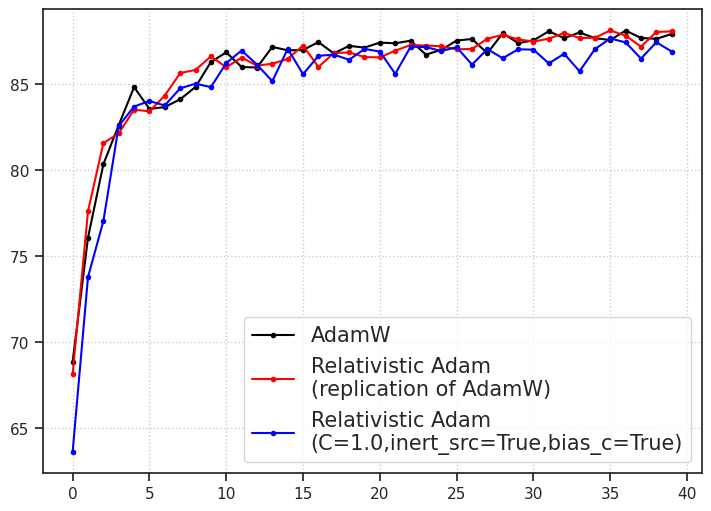

In [28]:
fig, ax = create_figure(1, 1, (7, 5))
ax.plot(results['AdamW']['test_acc'].squeeze(),
        color='k', marker='.', label='AdamW')
ax.plot(results['Relativistic Adam (C=inf,inert_src=False,bias_c=True)']['test_acc'].squeeze(),
        color='r', marker='.', label='Relativistic Adam\n(replication of AdamW)')
ax.plot(results['Relativistic Adam (C=1.0,inert_src=True,bias_c=True)']['test_acc'].squeeze(),
        color='b', marker='.', label='Relativistic Adam\n(C=1.0,inert_src=True,bias_c=True)')
ax.legend(fontsize=15)
ax.grid()
plt.show()

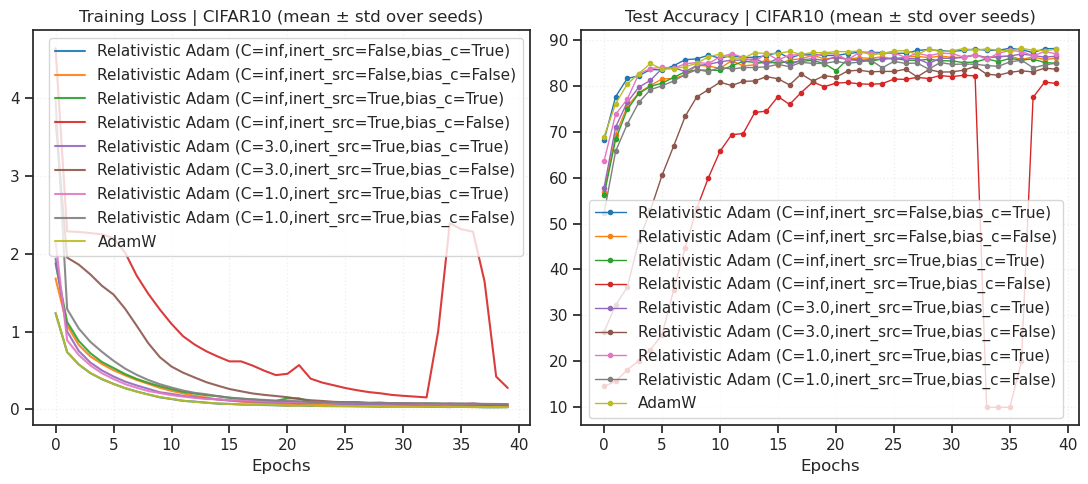

In [11]:
plot_results(results, title="CIFAR10 (mean ± std over seeds)")

### Low momenta

In [9]:
opt_kws = dict(lr=1e-3, betas=(0.8, 0.99))

experiments = [
#     Experiment(
#         name='Signum (m=20,beta=0.9)',
#         opt_fn=make_opt(RelativisticSignum, mass=20, momentum=0.9, **opt_kws)),
    Experiment(
        name='Relativistic Adam (C=inf)',
        opt_fn=make_opt(RelativisticAdam, coupling='inf', bias_correction=True, **opt_kws)),
    Experiment(
        name='Relativistic Adam (C=0.01)',
        opt_fn=make_opt(RelativisticAdam, coupling=0.01, bias_correction=True, **opt_kws)),
    Experiment(
        name='Relativistic Adam (C=1)',
        opt_fn=make_opt(RelativisticAdam, coupling=1, bias_correction=True, **opt_kws)),
    Experiment(
        name='Relativistic Adam (C=5)',
        opt_fn=make_opt(RelativisticAdam, coupling=5, bias_correction=True, **opt_kws)),
    Experiment(
        name='Relativistic Adam (C=100)',
        opt_fn=make_opt(RelativisticAdam, coupling=100, bias_correction=True, **opt_kws)),
    Experiment(
        name='Relativistic Adam (C=inf,bias_correction=False)',
        opt_fn=make_opt(RelativisticAdam, coupling='inf', bias_correction=False, **opt_kws)),
    Experiment(
        name='Relativistic Adam (C=0.01,bias_correction=False)',
        opt_fn=make_opt(RelativisticAdam, coupling=0.01, bias_correction=False, **opt_kws)),
    Experiment(
        name='Relativistic Adam (C=1,bias_correction=False)',
        opt_fn=make_opt(RelativisticAdam, coupling=1, bias_correction=False, **opt_kws)),
    Experiment(
        name='Relativistic Adam (C=5,bias_correction=False)',
        opt_fn=make_opt(RelativisticAdam, coupling=5, bias_correction=False, **opt_kws)),
    Experiment(
        name='Relativistic Adam (C=100,bias_correction=False)',
        opt_fn=make_opt(RelativisticAdam, coupling=100, bias_correction=False, **opt_kws)),
    Experiment(
        name='Adam',
        opt_fn=make_opt(torch.optim.Adam, **opt_kws)),
]

print(experiments)

[
    Experiment(name='Relativistic Adam (C=inf)', opt_fn=<function make_opt.<locals>._fn at 0x7f0fc80b1bc0>),
    Experiment(name='Relativistic Adam (C=0.01)', opt_fn=<function make_opt.<locals>._fn at 0x7f0fc80b1b20>),
    Experiment(name='Relativistic Adam (C=1)', opt_fn=<function make_opt.<locals>._fn at 0x7f0fc80b1d00>),
    Experiment(name='Relativistic Adam (C=5)', opt_fn=<function make_opt.<locals>._fn at 0x7f0fc80b1e40>),
    Experiment(name='Relativistic Adam (C=100)', opt_fn=<function make_opt.<locals>._fn at 0x7f0fc80b1ee0>),
    Experiment(
        name='Relativistic Adam (C=inf,bias_correction=False)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f0fc80b1f80>
    ),
    Experiment(
        name='Relativistic Adam (C=0.01,bias_correction=False)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f0fc80b2020>
    ),
    Experiment(
        name='Relativistic Adam (C=1,bias_correction=False)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f0fc80b20c0>
    ),
    Experiment(
        name='Relativistic Adam (C=5,bias_correction=False)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f0fc80b2160>
    ),
    Experiment(
        name='Relativistic Adam (C=100,bias_correction=False)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f0fc80b2200>
    ),
    Experiment(name='Adam', opt_fn=<function make_opt.<locals>._fn at 0x7f0fc80b22a0>)
]

In [10]:
%%time


results = run_experiments(experiments, cfg=cfg, seeds=[0])

--- Training (CIFAR10) ---

Model: ConvNet | seed=0
Optimizer: RelativisticAdam

RelativisticAdam (
Parameter Group 0
    betas: (0.8, 0.99)
    bias_correction: True
    coupling: inf
    eps: 1e-08
    lr: 0.001
    weight_decay: 0
)

Epoch    1/10:  Train Loss 2.0140  |  Test Acc 46.16%

Epoch    2/10:  Train Loss 1.2583  |  Test Acc 63.38%

Epoch    3/10:  Train Loss 0.8532  |  Test Acc 70.25%

...

Epoch    8/10:  Train Loss 0.2085  |  Test Acc 86.02%

Epoch    9/10:  Train Loss 0.1767  |  Test Acc 85.86%

Epoch   10/10:  Train Loss 0.1478  |  Test Acc 85.93%

Finished in 28.9s

CPU times: user 5min 51s, sys: 2.35 s, total: 5min 53s
Wall time: 5min 50s


In [11]:
avg_scores = {k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Relativistic Adam (C=0.01,bias_correction=False)': 74.81,
 'Relativistic Adam (C=0.01)': 74.82,
 'Relativistic Adam (C=100,bias_correction=False)': 84.03,
 'Relativistic Adam (C=inf)': 84.48,
 'Relativistic Adam (C=5,bias_correction=False)': 84.56,
 'Relativistic Adam (C=5)': 84.57,
 'Relativistic Adam (C=100)': 84.82,
 'Relativistic Adam (C=inf,bias_correction=False)': 84.98,
 'Relativistic Adam (C=1,bias_correction=False)': 85.04,
 'Relativistic Adam (C=1)': 85.21,
 'Adam': 85.55}

{'Relativistic Adam (m=10.0)': 88.61,
 'Relativistic Adam (m=100.0)': 88.7,
 'Adam': 88.73,
 'Relativistic Adam (m=1e8)': 88.78,
 'Relativistic Adam (m=1000.0)': 88.91,
 'Relativistic Adam (m=1.0)': 88.96}

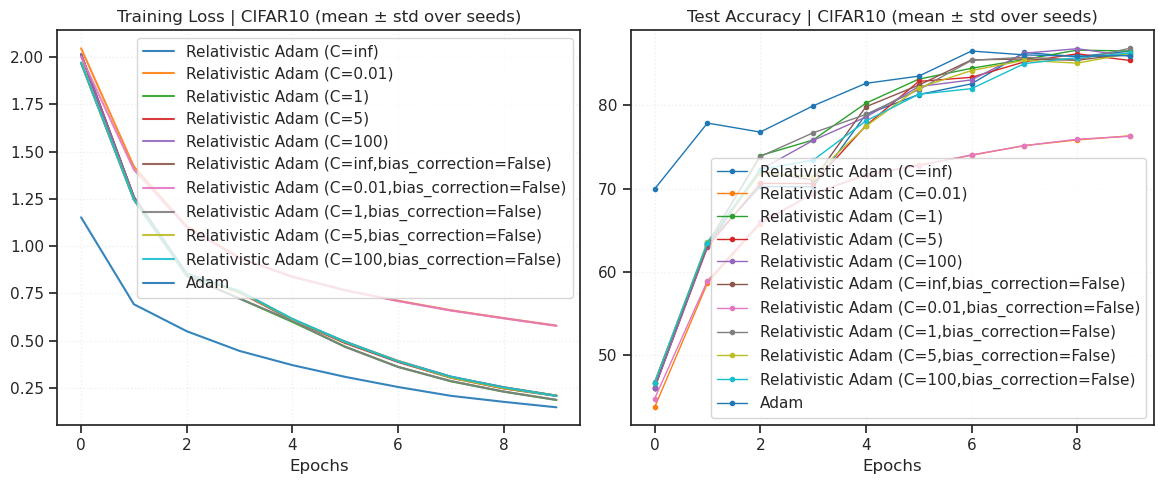

In [12]:
plot_results(results, title="CIFAR10 (mean ± std over seeds)")

### ImageNet32

`batch_size=256`

In [4]:
cfg = TrainConfig(
    dataset='ImageNet32',
    batch_size=256,
    epochs=200,
    device=device,
    data_on_device=False,
    verbose=True,
    amp=False,
)

In [6]:
opt_kws = dict(lr=1e-3, betas=(0.8, 0.99))

experiments = [
#     Experiment(
#         name='Relativistic Adam (m=1.0)',
#         opt_fn=make_opt(RelativisticAdam, mass=1.0, **opt_kws)),
    Experiment(
        name='Relativistic Adam (m=10.0)',
        opt_fn=make_opt(RelativisticAdam, mass=10.0, **opt_kws)),
#     Experiment(
#         name='Relativistic Adam (m=100.0)',
#         opt_fn=make_opt(RelativisticAdam, mass=100.0, **opt_kws)),
    Experiment(
        name='Relativistic Adam (m=1000.0)',
        opt_fn=make_opt(RelativisticAdam, mass=1000.0, **opt_kws)),
#     Experiment(
#         name='Relativistic Adam (m=1e8)',
#         opt_fn=make_opt(RelativisticAdam, mass=1e8, **opt_kws)),
    Experiment(
        name='Adam',
        opt_fn=make_opt(torch.optim.Adam, **opt_kws)),
]

print(experiments)

[
    Experiment(name='Relativistic Adam (m=10.0)', opt_fn=<function make_opt.<locals>._fn at 0x736ffdc40900>),
    Experiment(name='Relativistic Adam (m=1000.0)', opt_fn=<function make_opt.<locals>._fn at 0x736ffc00a8e0>),
    Experiment(name='Adam', opt_fn=<function make_opt.<locals>._fn at 0x736ffc00a7a0>)
]

In [7]:
%%time


results = run_experiments(
    experiments=experiments,
    cfg=cfg,
    model_class=ResNet18,
    model_kws=dict(num_classes=1000),
    seeds=[0],
)

--- Training (ImageNet32) ---

Model: ResNet18({'num_classes': 1000}) | seed=0
Optimizer: RelativisticAdam

RelativisticAdam (
Parameter Group 0
    betas: (0.8, 0.99)
    eps: 1e-08
    lr: 0.001
    mass: 10.0
    weight_decay: 0
)

Epoch    1/200:  Train Loss 5.0566  |  Test Acc 22.66%

Epoch    5/200:  Train Loss 1.8281  |  Test Acc 36.56%

Epoch   15/200:  Train Loss 0.4360  |  Test Acc 33.00%

...

Epoch  130/200:  Train Loss 0.0551  |  Test Acc 34.46%

Epoch  135/200:  Train Loss 0.0529  |  Test Acc 34.48%

Epoch  140/200:  Train Loss 0.0529  |  Test Acc 34.40%

Epoch  145/200:  Train Loss 0.0506  |  Test Acc 34.58%

KeyboardInterrupt: 

In [8]:
avg_scores = {k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

NameError: name 'results' is not defined

In [ ]:
plot_results(results, title="ImageNet32 (mean ± std over seeds)")

--- Training (ImageNet32) ---

Model: ResNet18({'num_classes': 1000}) | seed=0
Optimizer: RelativisticMemoryOptimizer

RelativisticMemoryOptimizer (
Parameter Group 0
    betas: (0.8, 0.99)
    lr: 0.001
    mass: 100
    weight_decay: 0.0
)

Epoch    1/100:  Train Loss 5.4199  |  Test Acc 9.92%

Epoch    5/100:  Train Loss 3.0106  |  Test Acc 26.54%

Epoch   10/100:  Train Loss 2.1650  |  Test Acc 32.08%

...

Epoch   85/100:  Train Loss 0.0124  |  Test Acc 35.42%

Epoch   90/100:  Train Loss 0.0101  |  Test Acc 35.39%

Epoch   95/100:  Train Loss 0.0082  |  Test Acc 35.52%

Epoch  100/100:  Train Loss 0.0073  |  Test Acc 35.35%

Finished in 15478.2s

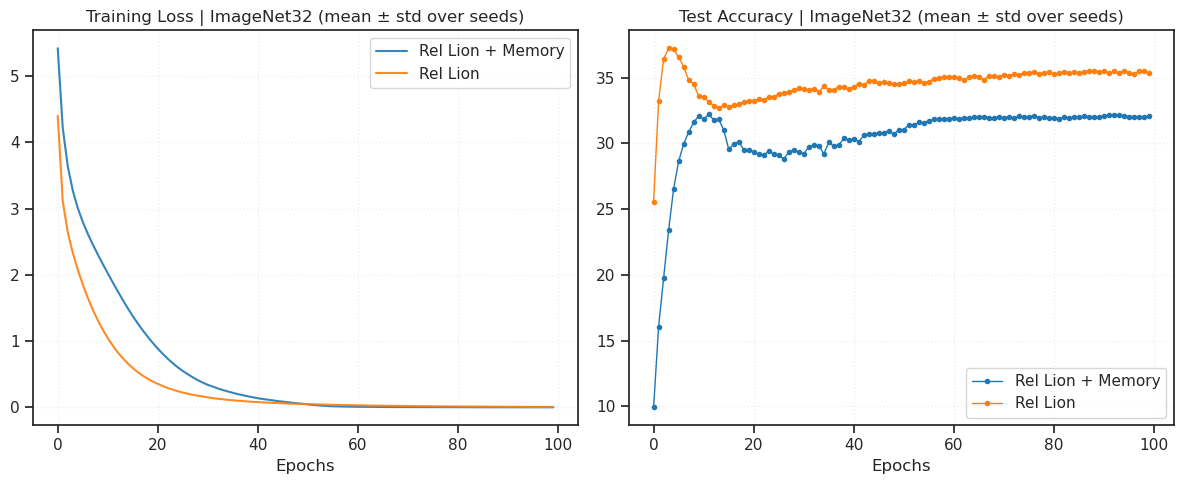

{'Rel Lion + Memory': 32.03, 'Rel Lion': 35.39}